In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [2]:
base_dir = Path("raw_data")

# class0_ellen_1_024.npy
filename_pattern = re.compile(r"(class[01])_([a-zA-Z0-9]+)_(\d+)_(\d+)\.npy$")

def extract_metadata(filepath: Path):
    """Extracts spectrogram metadata based on the filename and its content"""
    match = filename_pattern.match(filepath.name)
    if not match:
        print("Skipped (invalid format):", filepath.name)
        return None

    class_name, speaker, recording_id, segment_id = match.groups()

    try:
        mel = np.load(filepath)
    except Exception as e:
        print("Read error:", filepath.name, e)
        return None

    if mel.ndim != 2:
        print("Invalid dimensions:", filepath.name, mel.shape)
        return None

    return {
        "path": str(filepath),
        "dataset_split": filepath.parts[-3],  #train_data, test_data, validation_data
        "class_number": int(class_name[-1]),
        "class_name": class_name,
        "speaker": speaker,
        "recording_id": int(recording_id),
        "segment_id": int(segment_id),
        "n_mels": mel.shape[0],
        "n_frames": mel.shape[1],
        "mean": float(np.mean(mel)),
        "std": float(np.std(mel)),
    }


def collect_dataset(base_path: Path):
    """Collects all spectrograms and builds a DataFrame"""
    rows = []
    for f in base_path.rglob("*.npy"):
        meta = extract_metadata(f)
        if meta:
            rows.append(meta)
    return pd.DataFrame(rows)

In [3]:
print("Loading .npy files from:", base_dir)
df_mel = collect_dataset(base_dir)
print(f"Loaded {len(df_mel)} files\n")

df_mel.head()

Loading .npy files from: raw_data
Skipped (invalid format): class1_swift_1_000(1).npy
Skipped (invalid format): class1_swift_1_001(1).npy
Skipped (invalid format): class1_swift_1_002(1).npy
Skipped (invalid format): class1_swift_1_003(1).npy
Skipped (invalid format): class1_swift_1_004(1).npy
Skipped (invalid format): class1_swift_1_005(1).npy
Skipped (invalid format): class1_swift_1_006(1).npy
Skipped (invalid format): class1_swift_1_007(1).npy
Skipped (invalid format): class1_swift_1_008(1).npy
Skipped (invalid format): class1_swift_1_009(1).npy
Skipped (invalid format): class1_trisha_1_026(1).npy
Skipped (invalid format): class1_trisha_1_030(1).npy
Skipped (invalid format): class1_trisha_1_031(1).npy
Skipped (invalid format): class1_trisha_1_032(1).npy
Skipped (invalid format): class0_blanchett_3_151(1).npy
Skipped (invalid format): class0_blanchett_3_152(1).npy
Skipped (invalid format): class0_blanchett_3_153(1).npy
Skipped (invalid format): class0_blanchett_3_155(1).npy
Skipped (i

,path,dataset_split,class_number,class_name,speaker,recording_id,segment_id,n_mels,n_frames,mean,std
0,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,0,80,300,-0.001566,1.000898
1,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,1,80,300,0.000984,1.000880
2,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,2,80,300,-0.002190,0.999314
3,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,3,80,300,0.000641,1.001034
4,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,4,80,300,-0.000664,1.000385


In total, 5,043 spectrograms were loaded after excluding files that did not match the expected naming convention. All valid spectrograms were successfully processed.

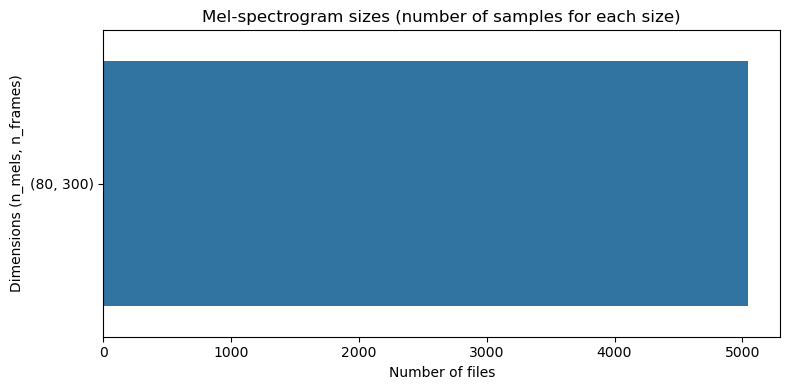

In [4]:
# Size distribution plot
df_mel["shape"] = df_mel.apply(lambda r: f"({r.n_mels}, {r.n_frames})", axis=1)

plt.figure(figsize=(8, 4))
sns.countplot(y="shape", data=df_mel, order=df_mel["shape"].value_counts().index)
plt.title("Mel-spectrogram sizes (number of samples for each size)")
plt.xlabel("Number of files")
plt.ylabel("Dimensions (n_mels, n_frames)")
plt.tight_layout()
plt.show()

All spectrograms have a consistent shape of 80 mel bins and 300 time frames, ensuring uniform input dimensions across the dataset. No variability in spectrogram size was observed between classes.

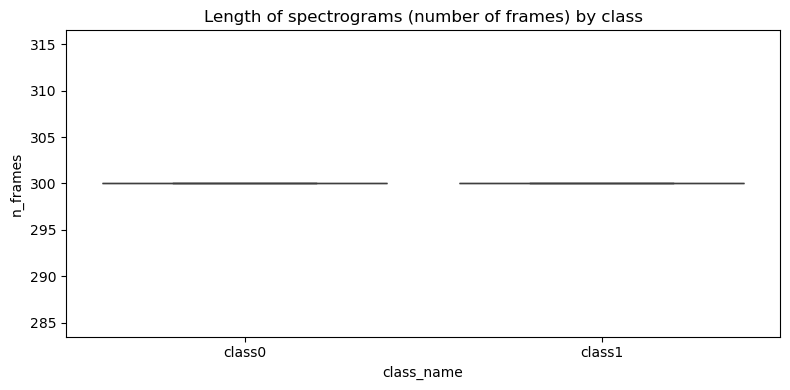

In [5]:
# Boxplot of n_frames by class
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_mel, x="class_name", y="n_frames")
plt.title("Length of spectrograms (number of frames) by class")
plt.ylabel("n_frames")
plt.xlabel("class_name")
plt.tight_layout()
plt.show()

All mel-spectrograms have consistent dimensions (80 mel bins, 300 frames).

In [6]:
# Statistical summary by class
stats = df_mel.groupby("class_name")[["mean", "std"]].describe().round(4)
display(stats)

mean                                                          \
             count    mean     std     min     25%     50%     75%     max   
class_name                                                                   
class0      2626.0 -0.0001  0.0017 -0.0045 -0.0013 -0.0001  0.0011  0.0076   
class1      2417.0 -0.0001  0.0018 -0.0052 -0.0015 -0.0002  0.0010  0.0096   

               std                                                          
             count    mean     std     min     25%     50%     75%     max  
class_name                                                                  
class0      2626.0  1.0002  0.0007  0.9924  0.9999  1.0004  1.0007  1.0015  
class1      2417.0  1.0003  0.0008  0.9877  0.9999  1.0004  1.0007  1.0015

Statistical analysis shows that the mean values of the spectrograms are centered around zero, while the standard deviations are close to one for both classes. The distributions of these statistics are highly similar across classes, with only minor variations. This confirms that the preprocessing steps were applied consistently and do not introduce class-dependent bias.

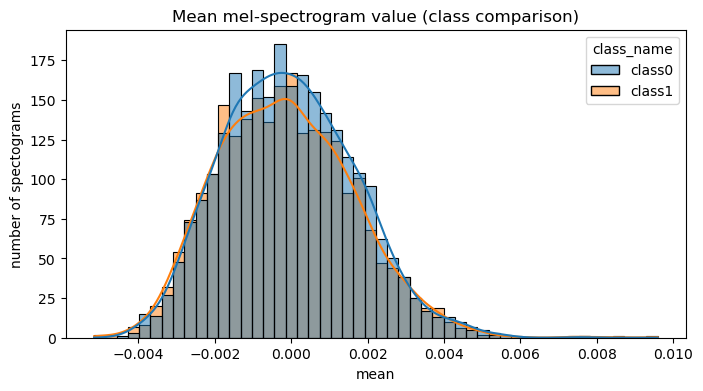

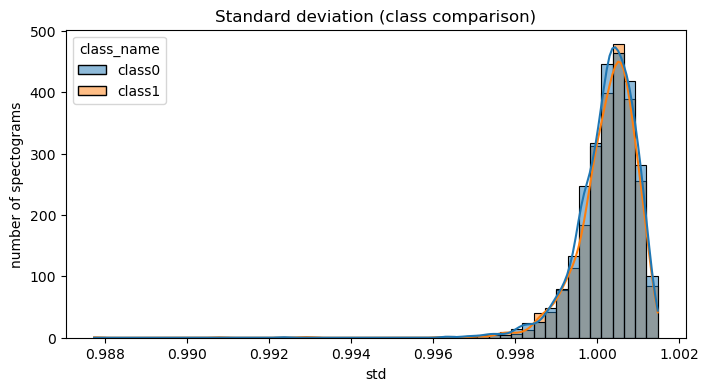

In [7]:
# Histograms of mean and std by class
plt.figure(figsize=(8, 4))
sns.histplot(df_mel, x="mean", hue="class_name", bins=50, kde=True)
plt.title("Mean mel-spectrogram value (class comparison)")
plt.xlabel("mean")
plt.ylabel("number of spectograms")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_mel, x="std", hue="class_name", bins=50, kde=True)
plt.title("Standard deviation (class comparison)")
plt.xlabel("std")
plt.ylabel("number of spectograms")
plt.show()

Histograms of spectrogram means and standard deviations demonstrate strong overlap between the two classes, indicating that simple global statistics are insufficient for class discrimination.

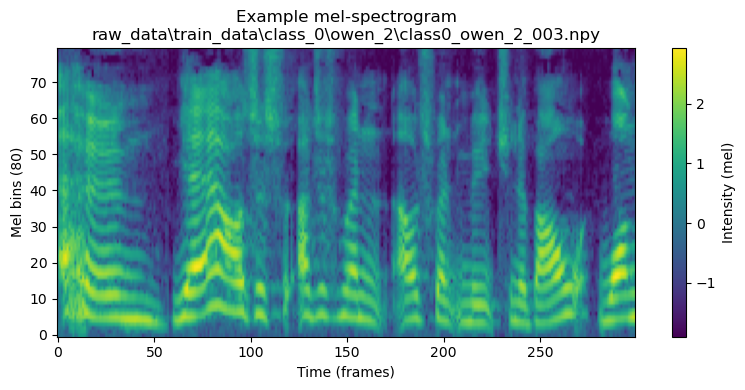

In [8]:
# Example mel-spectrogram visualization
example_path = df_mel.sample(1)["path"].iloc[0]
example = np.load(example_path)

plt.figure(figsize=(8, 4))
plt.imshow(example, aspect="auto", origin="lower")
plt.colorbar(label="Intensity (mel)")
plt.title(f"Example mel-spectrogram\n{example_path}")
plt.xlabel("Time (frames)")
plt.ylabel("Mel bins (80)")
plt.tight_layout()
plt.show()

In [ ]:
def incremental_sum(df):
    sum0 = None
    sum1 = None

    for _, row in df.iterrows():
        mel = np.load(row["path"])
        flat = mel.flatten()
        
        if row["class_number"] == 0:
            if sum0 is None:
                sum0 = np.zeros_like(flat)
            sum0 += flat
        else:
            if sum1 is None:
                sum1 = np.zeros_like(flat)
            sum1 += flat

    return sum0, sum1


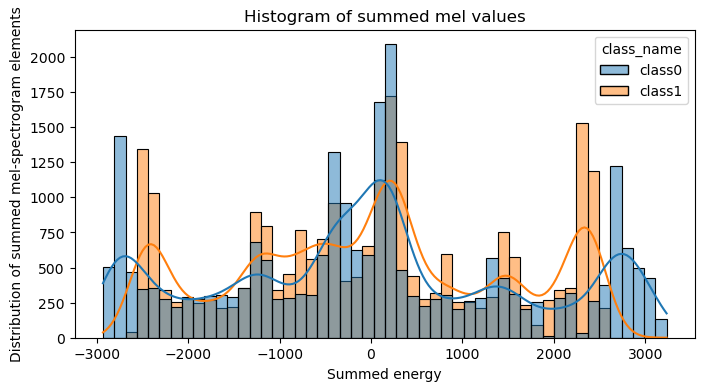

In [10]:
sum0, sum1 = incremental_sum(df_mel)

df_plot = pd.DataFrame({
    "energy": np.concatenate([sum0, sum1]),
    "class_name": ["class0"] * len(sum0) + ["class1"] * len(sum1)
})

plt.figure(figsize=(8, 4))
sns.histplot(data=df_plot, x="energy", hue="class_name",
             bins=50, kde=True, common_norm=False)
plt.title("Histogram of summed mel values")
plt.xlabel("Summed energy")
plt.ylabel("Distribution of summed mel-spectrogram elements")
plt.show()


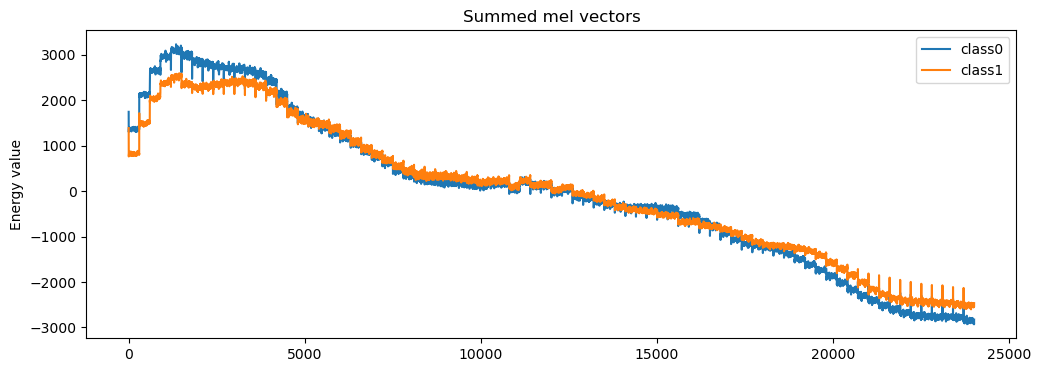

In [11]:
plt.figure(figsize=(12,4))
plt.plot(sum0, label="class0")
plt.plot(sum1, label="class1")
plt.ylabel("Energy value")
plt.title("Summed mel vectors")
plt.legend()
plt.show()


In [ ]:
def incremental_append(df):
    list0 = []
    list1 = []

    for _, row in df.iterrows():
        mel = np.load(row["path"])
        flat = mel.flatten()

        if row["class_number"] == 0:
            list0.extend(flat)
        else:
            list1.extend(flat)

    return list0, list1


list0, list1 = incremental_append(df_mel)


C:\Users\basie\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


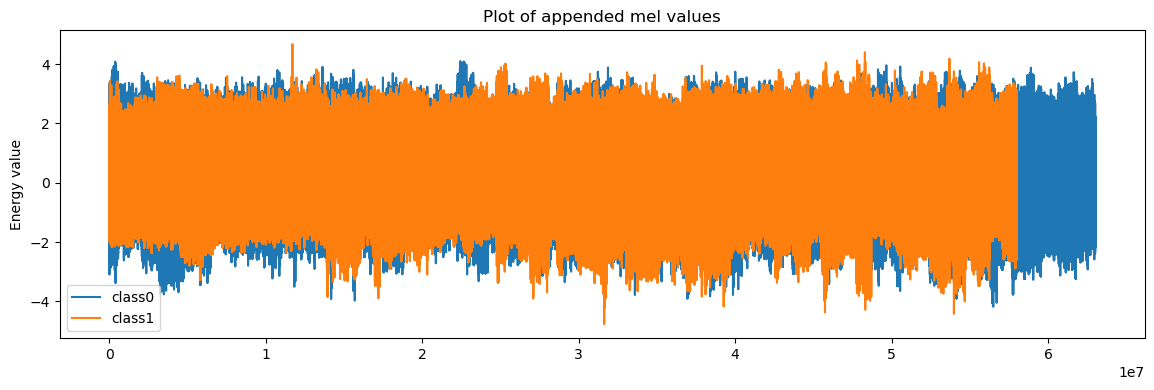

In [13]:
plt.figure(figsize=(14, 4))
plt.plot(list0, label="class0")
plt.plot(list1, label="class1")
plt.legend()
plt.ylabel("Energy value")
plt.title("Plot of appended mel values")
plt.show()


Energy-based analysis was conducted by aggregating spectrogram values across time and frequency. The distributions of summed and appended mel values show substantial overlap between classes, with only subtle differences in specific regions. While minor class-dependent trends can be observed in the summed energy representations, the overall distributions remain largely similar.

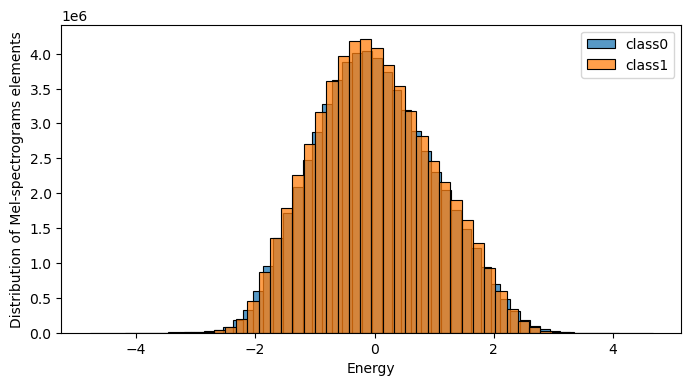

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(list0, bins=50, label="class0")
sns.histplot(list1, bins=50, label="class1")
plt.legend()
plt.xlabel("Energy")
plt.ylabel("Distribution of Mel-spectrograms elements")
plt.show()

In [15]:
# Histogram of mean energy over mel-bins and n_frames
def collect_histogram_data(df):
    mel_bins_means_class0 = []
    mel_bins_means_class1 = []
    time_means_class0 = []
    time_means_class1 = []

    for _, row in df.iterrows():
        mel = np.load(row["path"])

        mel_means = np.mean(mel, axis=1) 
        time_means = np.mean(mel, axis=0) 

        if row["class_number"] == 0:
            mel_bins_means_class0.append(mel_means)
            time_means_class0.append(time_means)
        else:
            mel_bins_means_class1.append(mel_means)
            time_means_class1.append(time_means)

    return {
        "mel_0": np.array(mel_bins_means_class0),
        "mel_1": np.array(mel_bins_means_class1),
        "time_0": np.array(time_means_class0),
        "time_1": np.array(time_means_class1)
    }

hist_data = collect_histogram_data(df_mel)

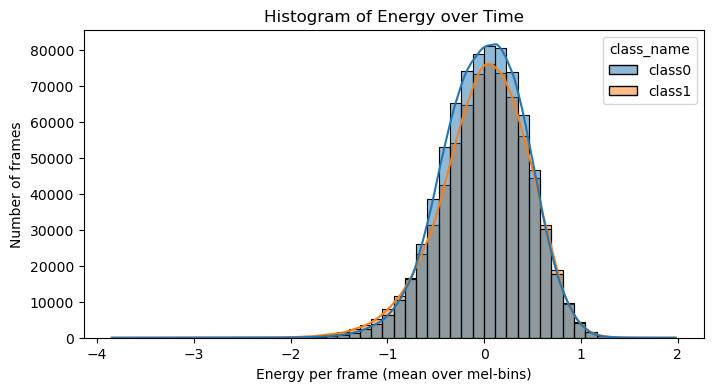

In [16]:
all_time_0 = hist_data["time_0"].flatten()
all_time_1 = hist_data["time_1"].flatten()

time_df = pd.DataFrame({
    "energy": np.concatenate([all_time_0, all_time_1]),
    "class_name": ["class0"] * len(all_time_0) + ["class1"] * len(all_time_1)
})

plt.figure(figsize=(8, 4))
sns.histplot(data=time_df, x="energy", hue="class_name",
             bins=50, kde=True, stat="count", common_norm=False)
plt.title("Histogram of Energy over Time")
plt.xlabel("Energy per frame (mean over mel-bins)")
plt.ylabel("Number of frames")
plt.show()

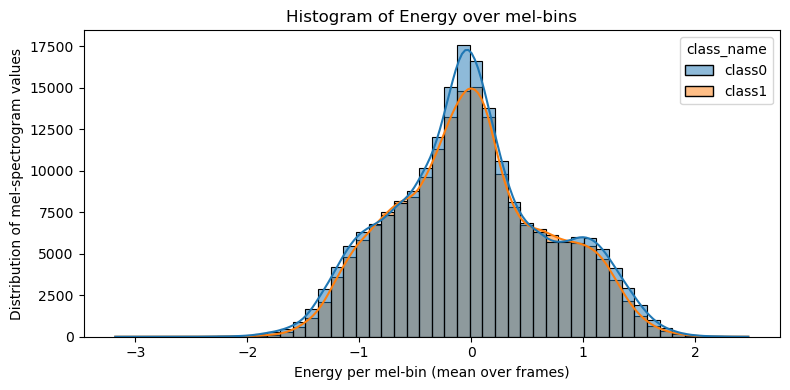

In [17]:

all_mel_0 = hist_data["mel_0"].flatten()
all_mel_1 = hist_data["mel_1"].flatten()

mel_df = pd.DataFrame({
    "energy": np.concatenate([all_mel_0, all_mel_1]),
    "class_name": ["class0"] * len(all_mel_0) + ["class1"] * len(all_mel_1)
})

plt.figure(figsize=(8, 4))
sns.histplot(data=mel_df, x="energy", hue="class_name",
             bins=50, kde=True, stat="count", common_norm=False)
plt.title("Histogram of Energy over mel-bins")
plt.xlabel("Energy per mel-bin (mean over frames)")
plt.ylabel("Distribution of mel-spectrogram values")

plt.tight_layout()
plt.show()

Further analysis of energy averaged over time frames and mel bins reveals nearly identical distributions for both classes. The energy per frame distribution is strongly overlapping, with differences primarily driven by the number of available samples rather than internal spectral characteristics. The energy distribution over mel bins exhibits presence of two dominant energy states in the audio data shared across classes.
